# Capstone project 2: DMart Analysis

In this project we have two sets of data: Training and Test. Our objective is to train a regression model on the training set and make it predict the revenue of each product at an outlet. We are going to use the variables available in the training set to train a multiple linear regression model for the same. 

In [1]:
#loading the dataset

import pandas as pd

dmart=pd.read_csv('C:\\Users\\sujoydutta\\Desktop\\Data analysis\\Python\\Projects\\Dmart sales analysis\\train (1).csv')
dmart.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
#examining the dataset
dmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [3]:
# Check for missing values in the the dataset
print("Missing values in train data:")
print(dmart.isnull().sum())

Missing values in train data:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [4]:
# Columns with missing values
missing_columns = dmart.columns[dmart.isnull().any()]
missing_columns

Index(['Item_Weight', 'Outlet_Size'], dtype='object')

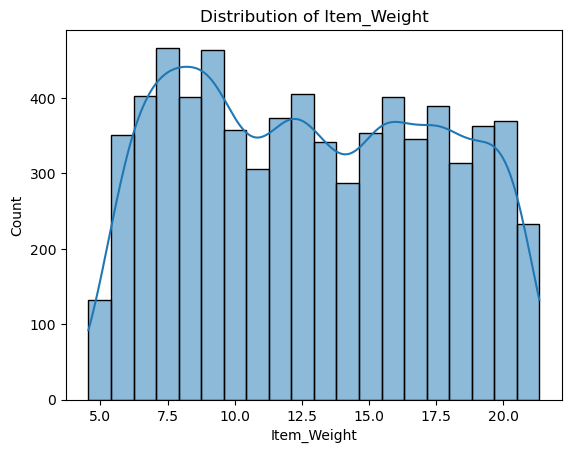

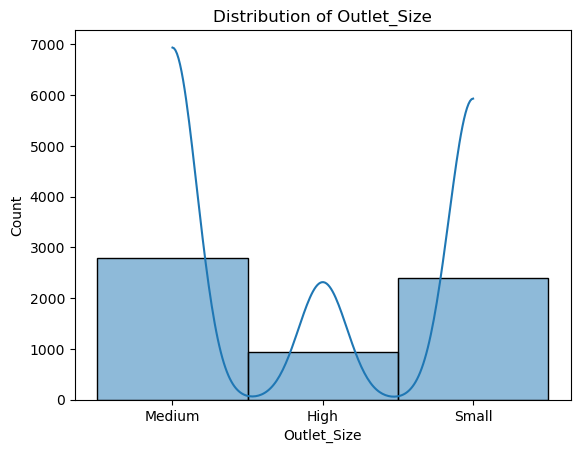

In [5]:
# Plotting distributions for columns with missing values

import seaborn as sb
import matplotlib.pyplot as plt

for col in missing_columns:
    sb.histplot(dmart[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

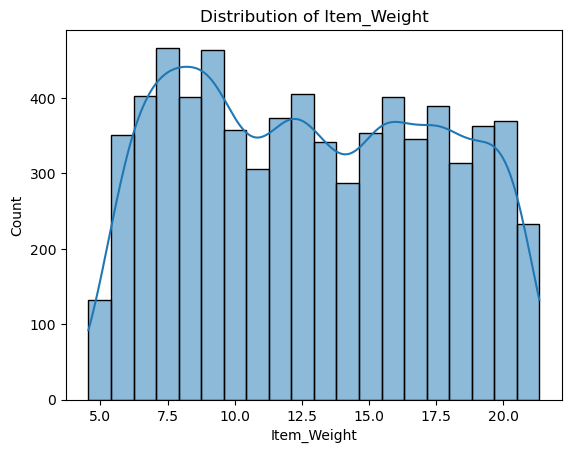

In [6]:
# Analyze the distribution of 'Item_Weight'
sb.histplot(dmart['Item_Weight'].dropna(), kde=True)
plt.title('Distribution of Item_Weight')
plt.show()

In [7]:

# Checking skewness
skewness = dmart['Item_Weight'].skew()
print(f'Skewness of Item_Weight: {skewness}')

Skewness of Item_Weight: 0.0824262091221237


In [8]:
# Imputing missing values 
if skewness > 1 or skewness < -1:
    
    dmart['Item_Weight'].fillna(dmart['Item_Weight'].median(), inplace=True)
else:

    dmart['Item_Weight'].fillna(dmart['Item_Weight'].mean(), inplace=True)


In [9]:
# Checking for missing values after imputation
print("Missing values in Item_Weight after imputation:", dmart['Item_Weight'].isnull().sum())

Missing values in Item_Weight after imputation: 0


In [10]:
#replacing missing values in categorical value in Outlet size variable 
dmart['Outlet_Size'].fillna(dmart['Outlet_Size'].mode()[0], inplace=True)


In [11]:
# Checking for missing values after imputation
print("Missing values in Outlet_Size after imputation:", dmart['Outlet_Size'].isnull().sum())

Missing values in Outlet_Size after imputation: 0


In [12]:
# Identifying numerical columns

numerical_columns=['Item_Weight', 'Item_Visibility', 'Item_MRP']
numerical_columns

['Item_Weight', 'Item_Visibility', 'Item_MRP']

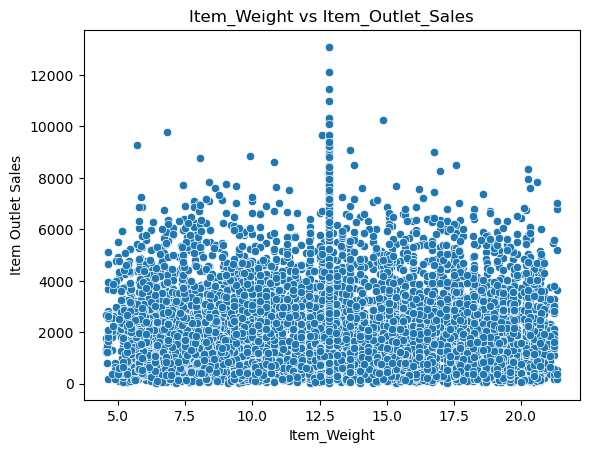

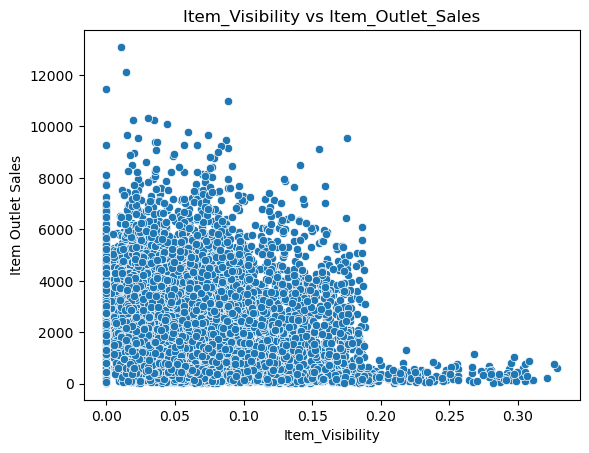

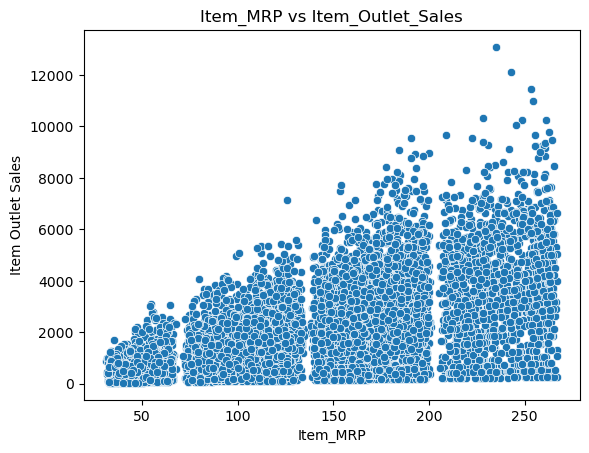

In [13]:
# Plotting scatter plots for each numerical feature vs target variable
for feature in numerical_columns:
    sb.scatterplot(x=dmart[feature], y=dmart['Item_Outlet_Sales'])
    plt.title(f'{feature} vs Item_Outlet_Sales')
    plt.xlabel(feature)
    plt.ylabel('Item Outlet Sales')
    plt.show()

In [14]:
# Calculate correlation coefficients with 'Sales'
correlations = dmart[numerical_columns].corrwith(dmart
                                                 ['Item_Outlet_Sales'])

correlations

Item_Weight        0.011550
Item_Visibility   -0.128625
Item_MRP           0.567574
dtype: float64

**Observation:** Only The MRP of Item is the variable that has strong correlation with the Item sale price rest other variables are bogus. 

In [15]:
#checking the VIF of numerical columns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Creating a DataFrame with only the numerical columns
numerical_data = dmart[numerical_columns]

# Adding a constant column for the intercept
numerical_data_with_const = sm.add_constant(numerical_data)

# Calculating VIF for each numerical feature
vif_data = pd.DataFrame()
vif_data['Feature'] = numerical_data_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(numerical_data_with_const.values, i) for i in range(numerical_data_with_const.shape[1])]

print(vif_data)

           Feature        VIF
0            const  16.795731
1      Item_Weight   1.000758
2  Item_Visibility   1.000146
3         Item_MRP   1.000614


**Observation:**  The VIF is low for all the variables hence no multicollinearity.

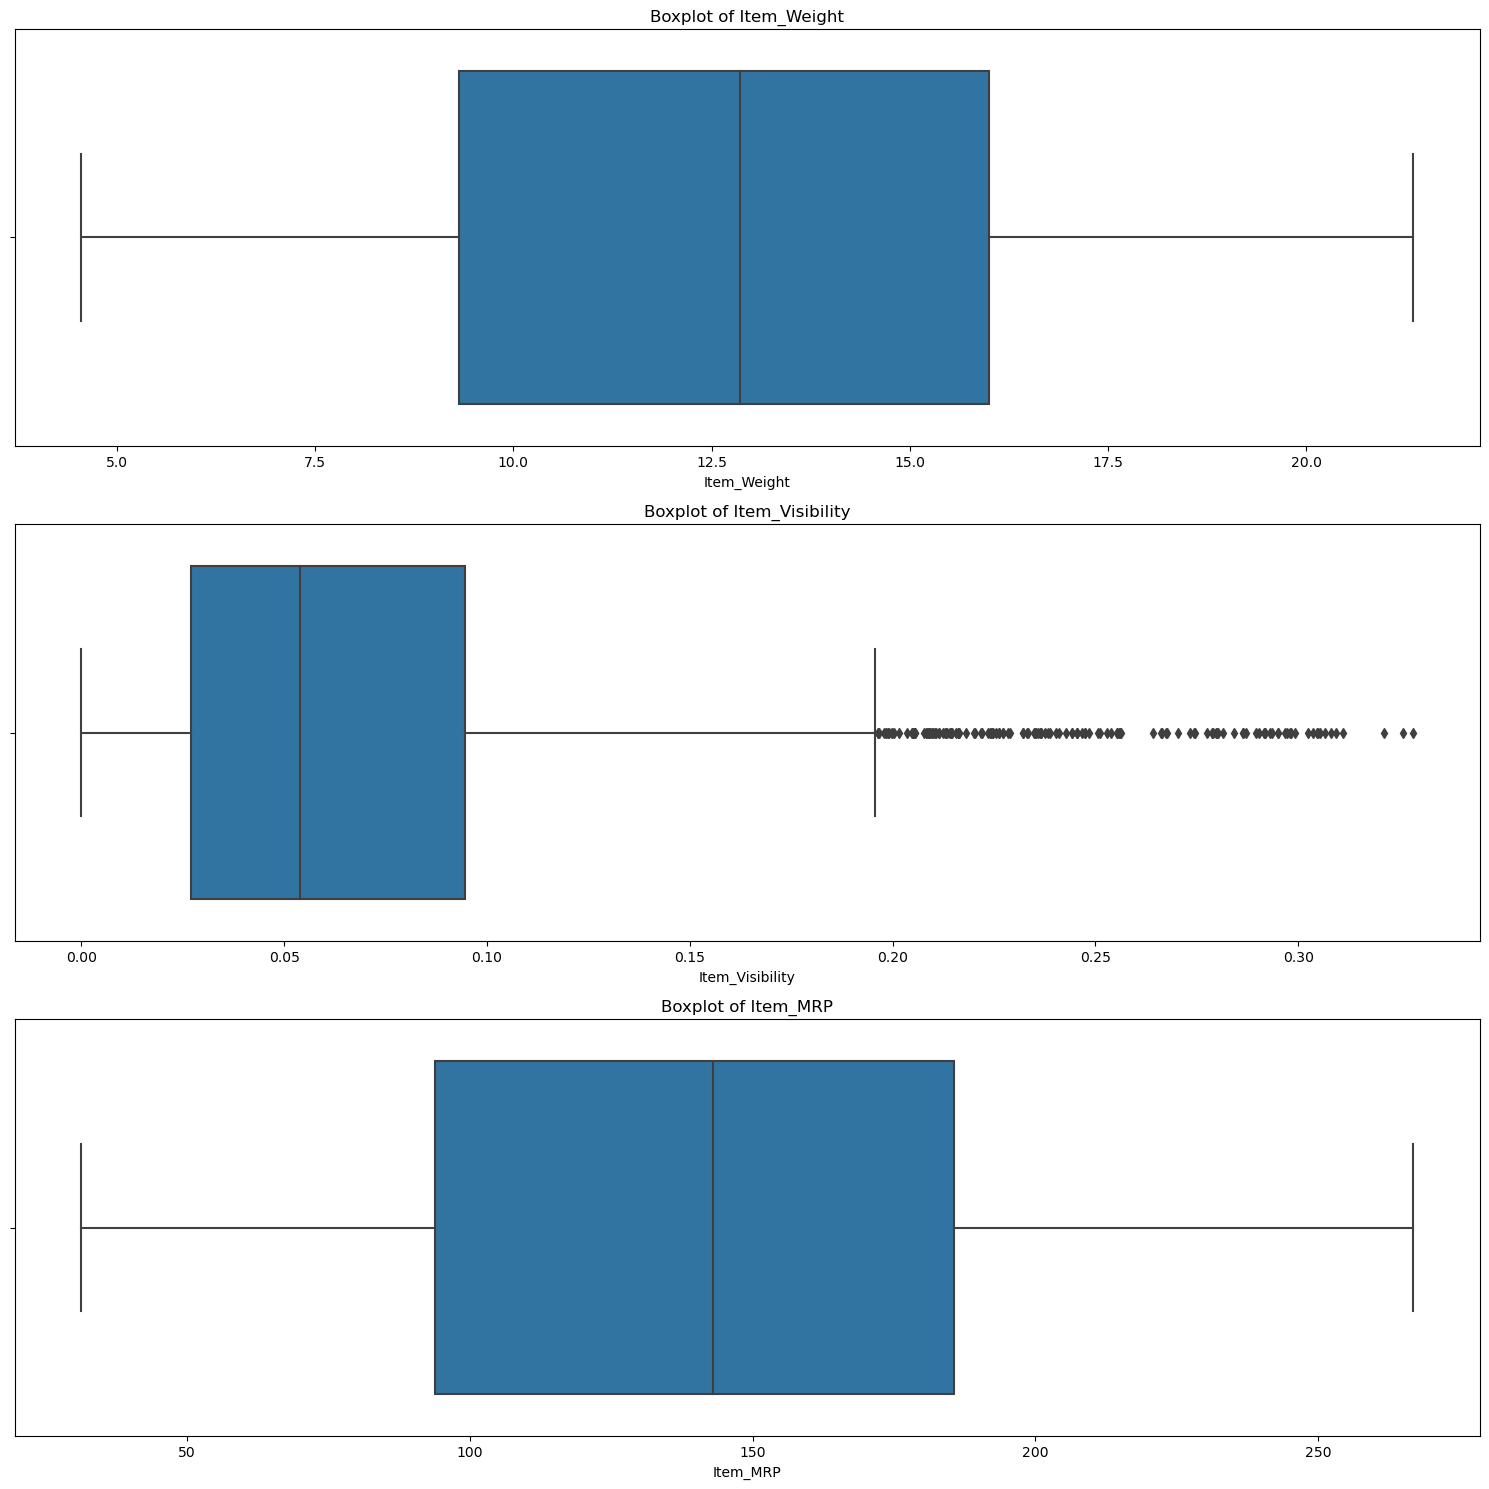

In [16]:
# Generating boxplots for each numerical column
plt.figure(figsize=(15, len(numerical_columns) * 5))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sb.boxplot(x=dmart[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

# Identifying outliers
column_name= 'Item_Visibility'
outliers = (dmart[column_name] > 0.18)

# Replacing outliers with NaN
dmart.loc[outliers, column_name] = np.nan

# Replacing NaN values with the mean of the column
mean_value = dmart[column_name].mean()
dmart[column_name].fillna(mean_value, inplace=True)

# viewing the cleaned column
print(dmart[column_name])


0       0.016047
1       0.019278
2       0.016760
3       0.000000
4       0.000000
          ...   
8518    0.056783
8519    0.046982
8520    0.035186
8521    0.145221
8522    0.044878
Name: Item_Visibility, Length: 8523, dtype: float64


Text(0.5, 0, 'Item_Visibility')

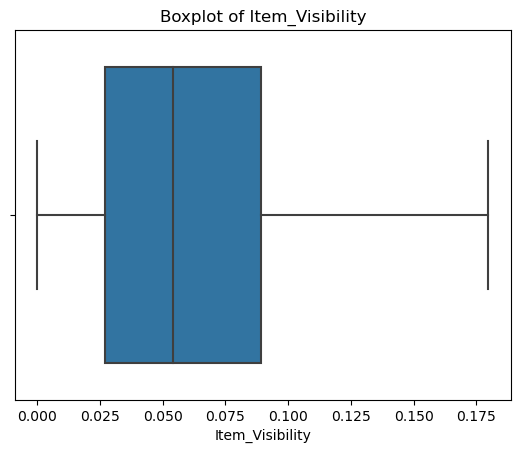

In [18]:
#checking if outliers are gone
column='Item_Visibility'
sb.boxplot(x=dmart[column])
plt.title(f'Boxplot of {column}')
plt.xlabel(column)


In [19]:
# Define the features and target variable
X = dmart[['Item_Weight', 'Item_Visibility', 'Item_MRP']]
y = dmart['Item_Outlet_Sales']

In [20]:
# Initializing linear regression models for each feature
from sklearn.linear_model import LinearRegression
model_weight = LinearRegression()
model_visibility = LinearRegression()
model_mrp = LinearRegression()


In [21]:
# Fit the models and predict sales
y_pred_weight = model_weight.fit(X[['Item_Weight']], y).predict(X[['Item_Weight']])
y_pred_visibility = model_visibility.fit(X[['Item_Visibility']], y).predict(X[['Item_Visibility']])
y_pred_mrp = model_mrp.fit(X[['Item_MRP']], y).predict(X[['Item_MRP']])


In [22]:
# Fitting the models and predict sales
y_pred_weight = model_weight.fit(X[['Item_Weight']], y).predict(X[['Item_Weight']])
y_pred_visibility = model_visibility.fit(X[['Item_Visibility']], y).predict(X[['Item_Visibility']])
y_pred_mrp = model_mrp.fit(X[['Item_MRP']], y).predict(X[['Item_MRP']])

In [23]:
# Calculating residuals for each feature
residuals_weight = y - y_pred_weight
residuals_visibility = y - y_pred_visibility
residuals_mrp = y - y_pred_mrp

Text(0.5, 1.0, 'Residuals for Item Weight')

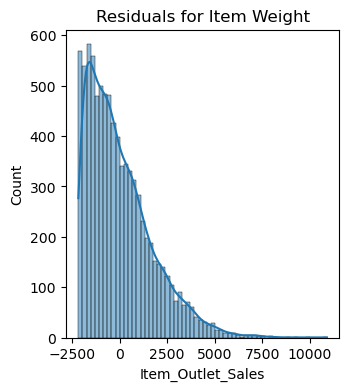

In [24]:
# Plotting residuals for Item Weight
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sb.histplot(residuals_weight, kde=True)
plt.title('Residuals for Item Weight')

Text(0.5, 1.0, 'Residuals for Item Visibility')

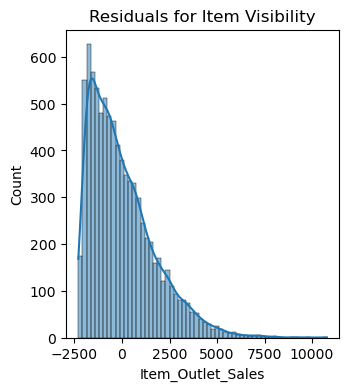

In [25]:
# Plotting residuals for Item Visibility
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sb.histplot(residuals_visibility, kde=True)
plt.title('Residuals for Item Visibility')


Text(0.5, 1.0, 'Residuals for Item MRP')

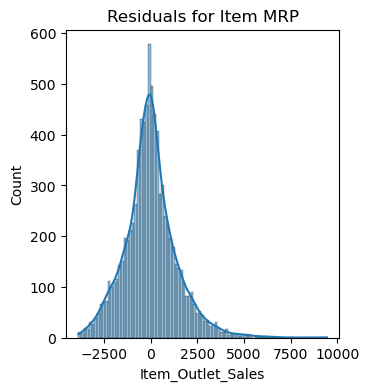

In [26]:
# Plotting residuals for Item MRP
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sb.histplot(residuals_mrp, kde=True)
plt.title('Residuals for Item MRP')


In [27]:
# Fitting the OLS model

X_const = sm.add_constant(X) 
ols_model = sm.OLS(y, X_const).fit()

In [28]:
# Checking the Durbin-Watson statistic to see if residuals are independent
dw_statistic = sm.stats.stattools.durbin_watson(ols_model.resid)
print(f'Durbin-Watson statistic: {dw_statistic}')

Durbin-Watson statistic: 1.9889158639615006


**Observation:** After the DW test we can safely say that since the co-efficient is almost 2, the residuals are independent and hence no autocorrelation.

Breusch-Pagan Test Results:
Lagrange Multiplier Statistic: 1201.466044010107
p-value: 3.52468474185158e-260
f-value: 465.9902005256882
f p-value: 2.2693497275266613e-280
Heteroscedasticity detected. Consider transforming the dependent variable.
Standard deviation of transformed residuals: 0.8686814332224075
The transformed residuals are not constant (standard deviation = 0.8686814332224075).


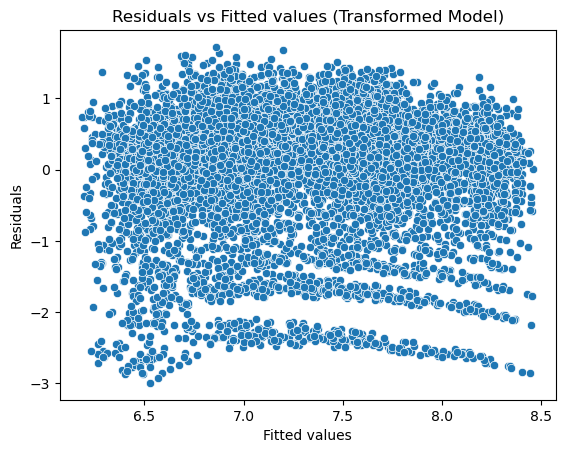

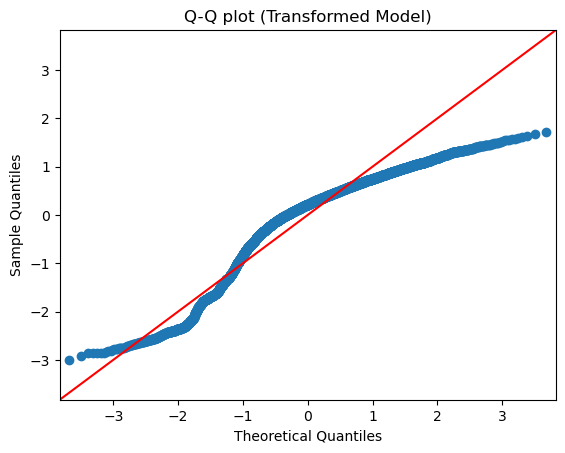

In [29]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns


# Fit the OLS model
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()

# Calculate the residuals
fitted_vals = model.predict(X)
residuals = y - fitted_vals

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X)
bp_test_results = dict(zip(['Lagrange Multiplier Statistic', 'p-value', 'f-value', 'f p-value'], bp_test))

print("Breusch-Pagan Test Results:")
for key, value in bp_test_results.items():
    print(f"{key}: {value}")

# Checking the p value
if bp_test_results['p-value'] < 0.01:
    print("Heteroscedasticity detected. Consider transforming the dependent variable.")
    # Log transformation of the dependent variable to stabilize variance
    y_transformed = np.log(y + 1)  # Adding 1 to avoid log(0)
    model_transformed = sm.OLS(y_transformed, X).fit()
    residuals_transformed = y_transformed - model_transformed.predict(X)
    residuals_transformed_std = residuals_transformed.std()
    print(f"Standard deviation of transformed residuals: {residuals_transformed_std}")

    # Check standard deviation of transformed residuals
    threshold_transformed = 0.1  # You can define your own threshold for transformed residuals
    if residuals_transformed_std > threshold_transformed:
        print(f"The transformed residuals are not constant (standard deviation = {residuals_transformed_std}).")
    else:
        print(f"The transformed residuals are approximately constant (standard deviation = {residuals_transformed_std}).")

    # Plot residuals vs fitted values for transformed model
    sns.scatterplot(x=model_transformed.predict(X), y=residuals_transformed)
    plt.title('Residuals vs Fitted values (Transformed Model)')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.show()

    # QQ plot for transformed residuals
    sm.qqplot(residuals_transformed, line='45')
    plt.title('Q-Q plot (Transformed Model)')
    plt.show()

else:
    print("No heteroscedasticity detected.")




**Observation:** The residuals are not following homoskedasticity, suggesting heteroskedasticity.

Standard deviation of square root transformed residuals: 15.103359651088299


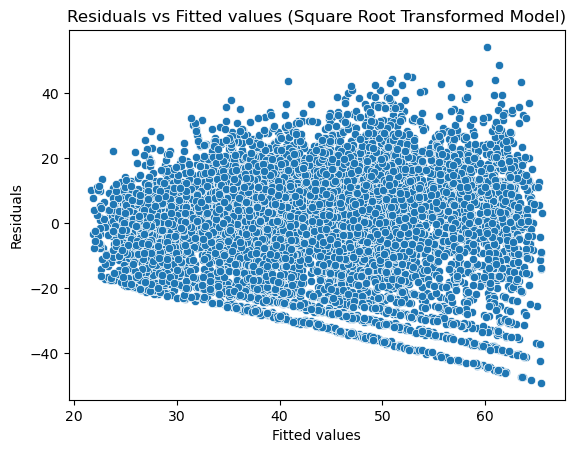

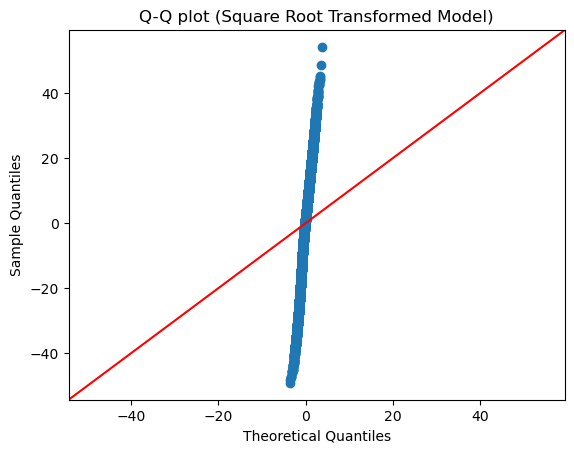

In [30]:
# Square root transformation of the dependent variable
y_sqrt = np.sqrt(y)

# Fit the OLS model with the square root transformed dependent variable
model_sqrt = sm.OLS(y_sqrt, X).fit()

# Calculate the residuals for the square root transformed model
fitted_vals_sqrt = model_sqrt.predict(X)
residuals_sqrt = y_sqrt - fitted_vals_sqrt

# Calculating standard deviation of square root transformed residuals
residuals_sqrt_std = residuals_sqrt.std()

print(f"Standard deviation of square root transformed residuals: {residuals_sqrt_std}")

# Plot residuals vs fitted values for square root transformed model
sns.scatterplot(x=fitted_vals_sqrt, y=residuals_sqrt)
plt.title('Residuals vs Fitted values (Square Root Transformed Model)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

# QQ plot for square root transformed residuals
sm.qqplot(residuals_sqrt, line='45')
plt.title('Q-Q plot (Square Root Transformed Model)')
plt.show()


Standard deviation of Box-Cox transformed residuals: 9.75277198203965
Breusch-Pagan Test Results (Box-Cox Transformation):
Lagrange Multiplier Statistic: 420.6900927074973
p-value: 7.29889236058533e-91
f-value: 147.44185879426445
f p-value: 3.762967219285152e-93


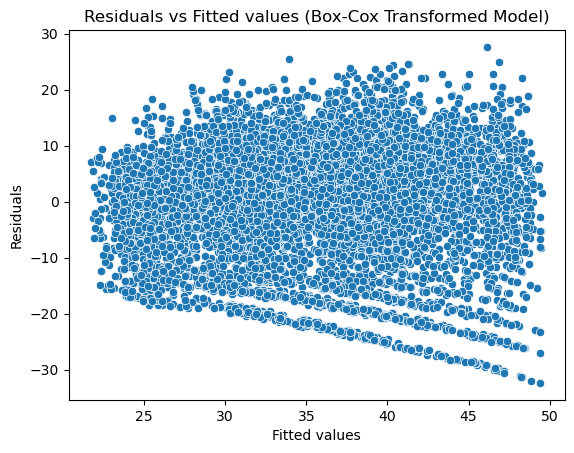

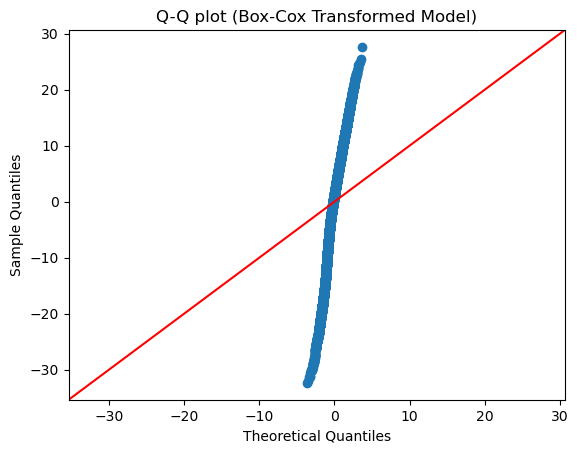

In [32]:
from scipy import stats
# Box-Cox transformation of the dependent variable
y_boxcox, fitted_lambda = stats.boxcox(y + 1)  # Adding 1 to avoid zero values

# Fit the OLS model with the Box-Cox transformed dependent variable
model_boxcox = sm.OLS(y_boxcox, X).fit()

# Calculate the residuals for the Box-Cox transformed model
fitted_vals_boxcox = model_boxcox.predict(X)
residuals_boxcox = y_boxcox - fitted_vals_boxcox

# Calculating standard deviation of Box-Cox transformed residuals
residuals_boxcox_std = residuals_boxcox.std()

# Perform Breusch-Pagan test
bp_test_boxcox = het_breuschpagan(residuals_boxcox, model_boxcox.model.exog)
labels = ['Lagrange Multiplier Statistic', 'p-value', 'f-value', 'f p-value']

print(f"Standard deviation of Box-Cox transformed residuals: {residuals_boxcox_std}")
print("Breusch-Pagan Test Results (Box-Cox Transformation):")
for label, value in zip(labels, bp_test_boxcox):
    print(f"{label}: {value}")

# Plot residuals vs fitted values for Box-Cox transformed model
sns.scatterplot(x=fitted_vals_boxcox, y=residuals_boxcox)
plt.title('Residuals vs Fitted values (Box-Cox Transformed Model)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

# QQ plot for Box-Cox transformed residuals
sm.qqplot(residuals_boxcox, line='45')
plt.title('Q-Q plot (Box-Cox Transformed Model)')
plt.show()


Standard deviation of square root transformed residuals: 15.103359651088299
Breusch-Pagan Test Results (Square Root Transformation):
Lagrange Multiplier Statistic: 755.7389022864681
p-value: 1.7182326418038062e-163
f-value: 276.293862473334
f p-value: 3.7933147728457425e-171


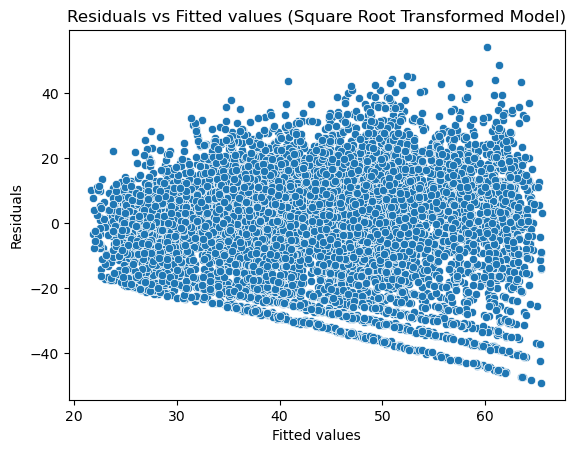

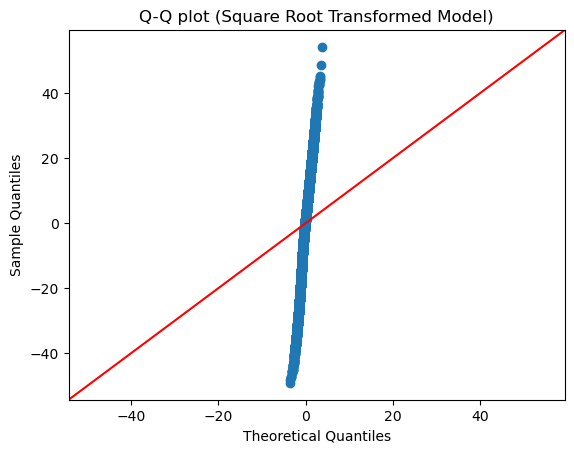

In [33]:

import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan

# Square root transformation of the dependent variable
y_sqrt = np.sqrt(y)

# Fit the OLS model with the square root transformed dependent variable
model_sqrt = sm.OLS(y_sqrt, X).fit()

# Calculate the residuals for the square root transformed model
fitted_vals_sqrt = model_sqrt.predict(X)
residuals_sqrt = y_sqrt - fitted_vals_sqrt

# Calculating standard deviation of square root transformed residuals
residuals_sqrt_std = residuals_sqrt.std()

# Perform Breusch-Pagan test
bp_test_sqrt = het_breuschpagan(residuals_sqrt, model_sqrt.model.exog)
labels = ['Lagrange Multiplier Statistic', 'p-value', 'f-value', 'f p-value']

print(f"Standard deviation of square root transformed residuals: {residuals_sqrt_std}")
print("Breusch-Pagan Test Results (Square Root Transformation):")
for label, value in zip(labels, bp_test_sqrt):
    print(f"{label}: {value}")

# Plot residuals vs fitted values for square root transformed model
sns.scatterplot(x=fitted_vals_sqrt, y=residuals_sqrt)
plt.title('Residuals vs Fitted values (Square Root Transformed Model)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

# QQ plot for square root transformed residuals
sm.qqplot(residuals_sqrt, line='45')
plt.title('Q-Q plot (Square Root Transformed Model)')
plt.show()


**Observation:** After performing the transformations we have failed to address the issue of heteroskedasticity.


In [34]:
# Get R-squared value
rsquared = ols_model.rsquared


In [35]:
#checking if the residuals are normally distributed or not
from scipy.stats import shapiro

# Perform Shapiro-Wilk test for normality on residuals
shapiro_test = shapiro(residuals)

# Extract the test statistic and p-value
test_statistic, p_value = shapiro_test

# Define significance level
alpha = 0.05

# Print the Shapiro-Wilk test result for the overall sample
print('Overall Shapiro-Wilk test result:')
print(f'Shapiro-Wilk test statistic: {test_statistic}')
print(f'p-value: {p_value}')
if p_value > alpha:
    print('The residuals appear to be normally distributed (fail to reject H0).')
else:
    print('The residuals do not appear to be normally distributed (reject H0).')

Overall Shapiro-Wilk test result:
Shapiro-Wilk test statistic: 0.974132239818573
p-value: 1.3632411710619928e-36
The residuals do not appear to be normally distributed (reject H0).


C:\Users\sujoydutta\anaconda\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


**Observation:** The assumption of normal distribution of residuals has been violated in our case. 

In [36]:
# Selecting non-numeric columns
categorical_columns = dmart.select_dtypes(exclude=['number']).columns

categorical_columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [41]:
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables using LabelEncoder
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    dmart[column] = le.fit_transform(dmart[column].astype(str))
    label_encoders[column] = le

In [51]:
# Defining the dependent variable
dependent_var = 'Item_Outlet_Sales'

# Define X (independent variables) and y (dependent variable)
X = dmart.drop(dependent_var, axis=1)
y = dmart[dependent_var]


In [54]:
# Add a constant term to the independent variables matrix for the intercept
X = sm.add_constant(X)

In [55]:
# Fitting the MLR model
model = sm.OLS(y, X).fit()

In [56]:
# Printing the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     802.6
Date:                Sat, 22 Jun 2024   Prob (F-statistic):               0.00
Time:                        16:46:38   Log-Likelihood:                -72490.
No. Observations:                8523   AIC:                         1.450e+05
Df Residuals:                    8511   BIC:                         1.451e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [57]:
#getting tools 
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


In [58]:
#trying other methods

# Ridge Regression
ridge_model = Ridge(alpha=1.0)  
ridge_model.fit(X, y)
ridge_pred = ridge_model.predict(X)
ridge_r2 = r2_score(y, ridge_pred)
print("Ridge Regression R-squared:", ridge_r2)





Ridge Regression R-squared: 0.5091413514883474


In [59]:
# Lasso Regression

lasso_model = Lasso(alpha=1.0)  
lasso_model.fit(X, y)
lasso_pred = lasso_model.predict(X)
lasso_r2 = r2_score(y, lasso_pred)
print("Lasso Regression R-squared:", lasso_r2)

Lasso Regression R-squared: 0.5089564090028911


In [60]:
# K-Nearest Neighbors Regression
knn_model = KNeighborsRegressor(n_neighbors=5)  
knn_model.fit(X, y)
knn_pred = knn_model.predict(X)
knn_r2 = r2_score(y, knn_pred)
print("KNN Regression R-squared:", knn_r2)


KNN Regression R-squared: 0.45363277213079367


In [61]:

# Random Forest Regression
forest_model = RandomForestRegressor(n_estimators=100, max_depth=3)  
forest_model.fit(X, y)
forest_pred = forest_model.predict(X)
forest_r2 = r2_score(y, forest_pred)
print("Random Forest Regression R-squared:", forest_r2)

Random Forest Regression R-squared: 0.5374700470224998


**Conclusion:** We can conclude Random Forest Regression has the best fit as its R squared is the highest and we are going to use that model to predict the missing values in the test. It has a R score of 54%.

In [50]:
#importing the test dataset 

test=pd.read_csv('C:\\Users\\sujoydutta\\Desktop\\Data analysis\\Python\\Projects\\Dmart sales analysis\\test (1).csv')
test.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [62]:
#examining the dataset
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [63]:
# Check for missing values in the the dataset
print("Missing values in train data:")
print(test.isnull().sum())

Missing values in train data:
Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64


In [64]:
#replacing the missing values
test['Item_Weight'].fillna(test['Item_Weight'].mean(), inplace=True)
test['Outlet_Size'].fillna(test['Outlet_Size'].mode()[0], inplace=True)

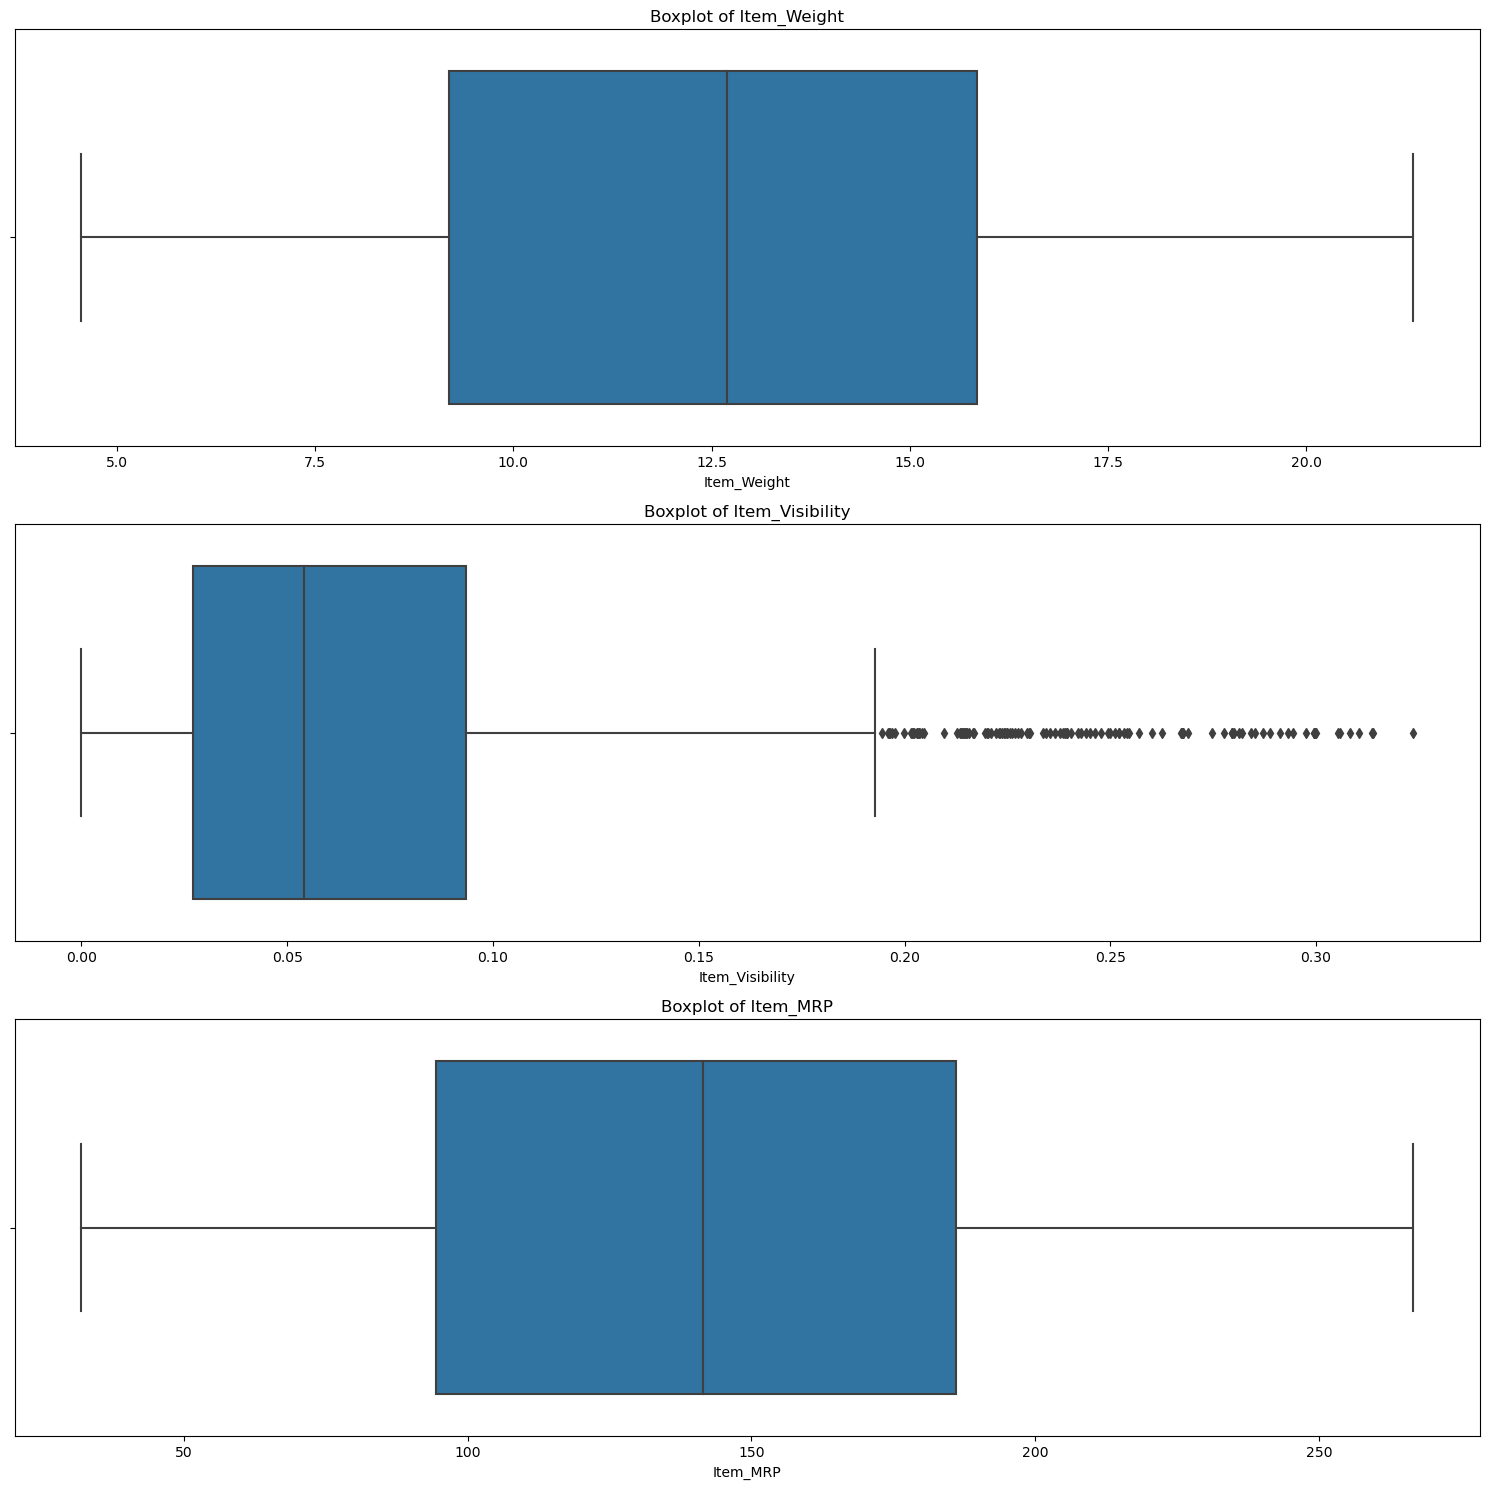

In [65]:
#Generating boxplots for each numerical column
plt.figure(figsize=(15, len(numerical_columns) * 5))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sb.boxplot(x=test[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
plt.tight_layout()
plt.show()

In [66]:
# Identifying outliers
column_name= 'Item_Visibility'
outliers = (test[column_name] > 0.18)

# Replacing outliers with NaN
test.loc[outliers, column_name] = np.nan

# Replacing NaN values with the mean of the column
mean_value = test[column_name].mean()
test[column_name].fillna(mean_value, inplace=True)

# viewing the cleaned column
print(test[column_name])

0       0.007565
1       0.038428
2       0.099575
3       0.015388
4       0.118599
          ...   
5676    0.013496
5677    0.142991
5678    0.073529
5679    0.000000
5680    0.104720
Name: Item_Visibility, Length: 5681, dtype: float64


In [67]:

# Create an empty column named 'Predicted_Item_Outlet_Sales'
test['Predicted_Item_Outlet_Sales'] = None  


In [68]:
#examining the dataset
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Predicted_Item_Outlet_Sales
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,None
1,FDW14,8.300000,reg,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,None
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,None
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,None
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,None


In [70]:
# Defining the dependent variable
dependent_var = 'Predicted_Item_Outlet_Sales'

In [71]:
# Define X (independent variables) and y (dependent variable)
X = test.drop(dependent_var, axis=1)
y = test[dependent_var]

In [72]:
# Encode categorical variables using LabelEncoder
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column].astype(str))
    label_encoders[column] = le

In [73]:
# Add constant term to the independent variables
X = sm.add_constant(X)

In [74]:
# Predict the missing values using the trained model
predicted_values = forest_model.predict(X)
predicted_values

array([1908.07056398, 1677.9002176 ,  563.80391766, ..., 1908.07056398,
       3173.67589274, 1379.74090294])

In [76]:
# Filling the empty column in the dataset with the predicted values
test[dependent_var] = np.where(test[dependent_var].isnull(), predicted_values, test[dependent_var])


In [78]:
# Printing the dataset to check the filled values
test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Predicted_Item_Outlet_Sales
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1908.070564
1,FDW14,8.300000,reg,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,1677.900218
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,563.803918
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,3001.085239
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,5085.137817
